<a href="https://www.kaggle.com/code/mansi26garg/catboost-algorithm-explain-using-simple-math?scriptVersionId=329108426" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# CatBoost Actual (Step-by-Step)

CatBoost (Categorical Boosting) is a gradient boosting algorithm that builds decision trees sequentially while handling categorical features using **Ordered Target Statistics (CTR)** and **Ordered Boosting**.

```text
Price
   ↓
Mean Prior (142)
   ↓
Random Permutation
   ↓
Ordered CTR
   ↓
Ordered Prediction
   ↓
Gradient = Prediction - Actual
   ↓
Gain Calculation
   ↓
Best Split
   ↓
Leaf Values = -G/(H+λ)
   ↓
Tree Output
   ↓
Prediction Update
   ↓
Repeat
```

This code demonstrates the core CatBoost ideas:

1. **Ordered Target Encoding (CTR)** to avoid leakage.
2. **Ordered Boosting** to avoid prediction shift.
3. **Gradient Boosting** using residuals.
4. **Regularized leaf values** (-G/(H+lambda)).
5. **Learning-rate updates** 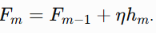

A true CatBoost depth-2 tree would require two levels of symmetric splits, producing 4 leaves, and depth-3 would produce 8 leaves.


# Catboost Algorithm mathematical step with small data 
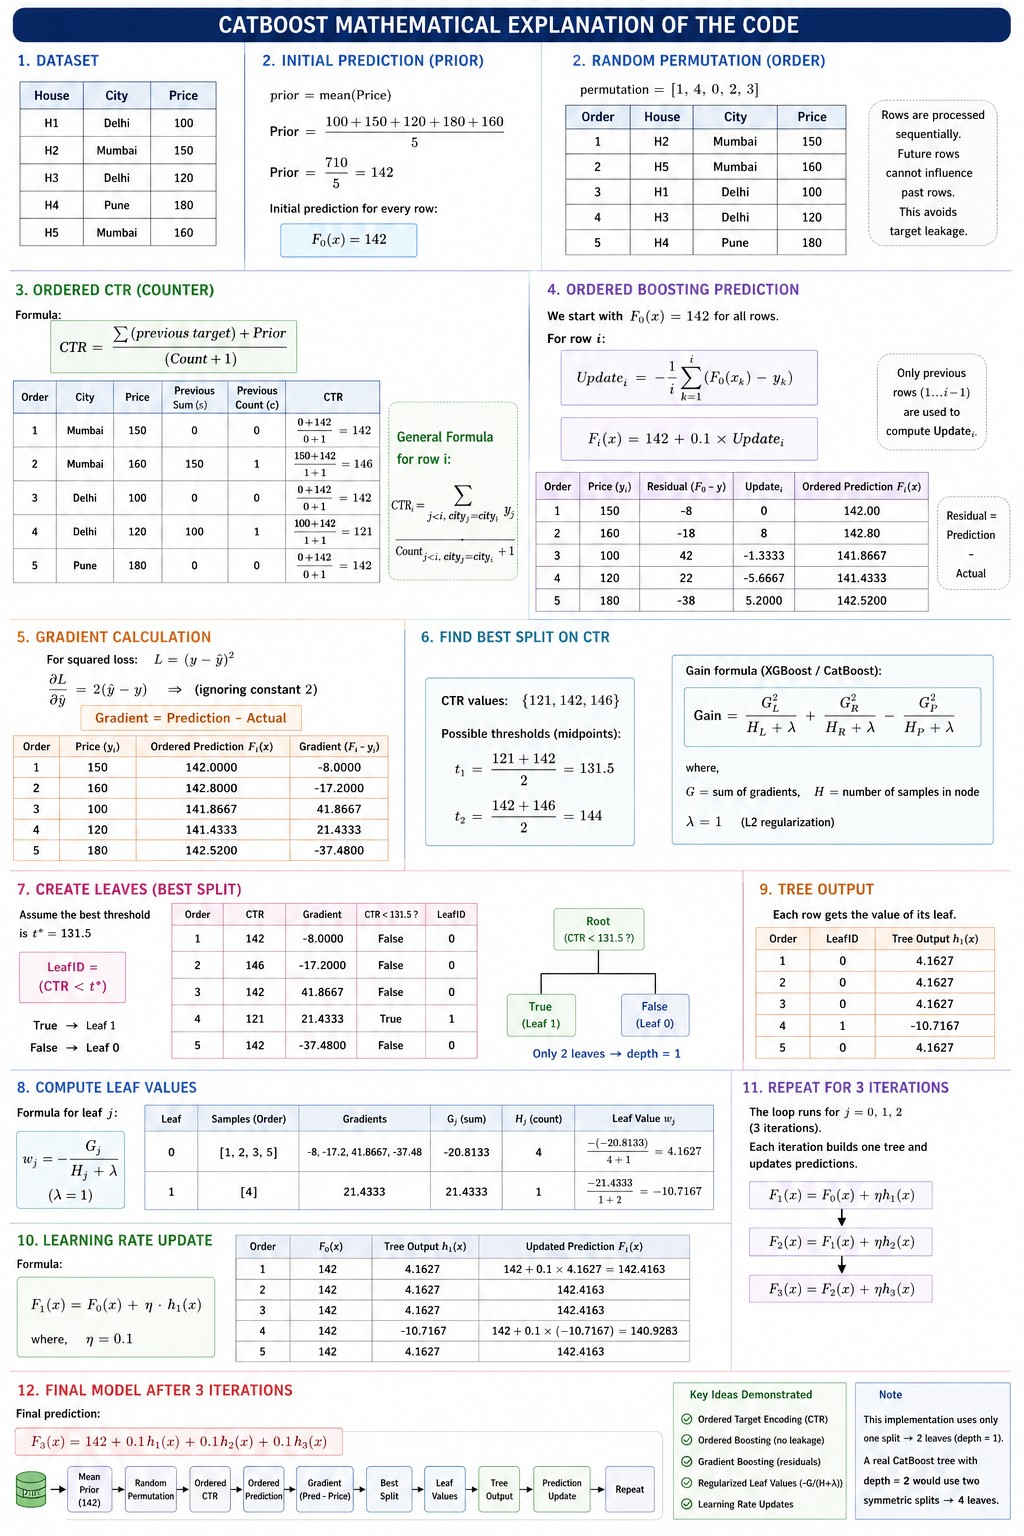

# CatBoost Code using Mathematical manual

In [1]:
# CatBoost Mathematical Example
# Dataset: House - City - Price

import pandas as pd
import numpy as np
from tabulate import tabulate
from catboost import CatBoostRegressor

# ----------------------------------
# Step 1: Create Dataset
# ----------------------------------

df = pd.DataFrame({
    'House': ['H1', 'H2', 'H3', 'H4', 'H5'],
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Pune', 'Mumbai'],
    'Price': [100, 150, 120, 180, 160]
})

print("Original Data")
print(df)

# =====================================================
# STEP 2: Initial Prediction
# F0(x) = Mean(Target)
#
# F0(x) = (100+150+120+180+160)/5
#       = 142
#
# Every row initially predicts 142
# =====================================================

prior = df['Price'].mean()

perm_df = df
perm_df['Predication'] = prior


# =====================================================
# STEP 3: Random Permutation
#
# CatBoost uses random ordering to avoid target leakage
# =====================================================

permutation = [1,4,0,2,3]
perm_df = perm_df.iloc[permutation].copy()

# =====================================================
# Number of boosting iterations
# =====================================================

iteration = 3
for j in range(iteration):
    print("\n\nIteration = ",j+1)
    
    # =================================================
    # STEP 4: Ordered CTR Calculation
    #
    # CTR =
    # (Previous Category Sum + Prior)
    # --------------------------------
    # (Previous Category Count + 1)
    #
    # Example:
    #
    # Mumbai first occurrence
    # CTR=(0+142)/(0+1)=142
    #
    # Mumbai second occurrence
    # CTR=(150+142)/(1+1)=146
    # =================================================
    
    city_sum = {}
    city_count = {}
    
    ctr_values = []
    
    for _, row in perm_df.iterrows():
    
        city = row['City']
    
        s = city_sum.get(city,0)
        c = city_count.get(city,0)
    
        ctr = (s + prior)/(c + 1)
    
        ctr_values.append(ctr)
    
        city_sum[city] = s + row['Price']
        city_count[city] = c + 1
    
    perm_df['CTR'] = ctr_values

    # =================================================
    # STEP 5: Ordered Prediction
    #
    # Only previous rows are used
    #
    # Gradient:
    #
    # g = Prediction - Actual
    #
    # Update:
    #
    # Pred = Prior + η(-mean(g))
    #
    # This mimics CatBoost Ordered Boosting
    # =================================================
    
    ordered_pred = []

    for i in range(len(perm_df)):

        if i == 0:
            ordered_pred.append(prior)
    
        else:
            G = (
                perm_df['Predication'].iloc[:i]
                - perm_df['Price'].iloc[:i]
            )
    
            update = -G.mean()
    
            ordered_pred.append(prior + 0.1 * update)
    
    perm_df['Ordered_Predication'] = ordered_pred

    # =================================================
    # STEP 6: Gradient Calculation
    #
    # Squared Error Loss
    #
    # L = 1/2(y - F)^2
    #
    # Gradient:
    #
    # g = F - y
    # =================================================
    
    perm_df['Gradient'] = (perm_df['Ordered_Predication']-perm_df['Price'])

    # =================================================
    # STEP 7: Regularization Parameter
    #
    # λ prevents overly large leaf values
    # =================================================
    
    lambda_reg = 1

    # =================================================
    # STEP 8: Split Gain Calculation
    #
    # Gain = GL²/(HL+λ) + GR²/(HR+λ) - GP²/(HP+λ)
    #
    # Choose split with maximum gain
    # =================================================
    
    def score_split(feature, threshold, gradients):
        left = gradients[feature < threshold]
        right = gradients[feature >= threshold]
    
        if len(left) == 0 or len(right) == 0:
            return -np.inf
    
        G_left = left.sum()
        H_left = len(left)
    
        G_right = right.sum()
        H_right = len(right)
    
        G_parent = G_left + G_right
        H_parent = H_left + H_right
    
        gain = (
            (G_left ** 2) / (H_left + lambda_reg)
            +
            (G_right ** 2) / (H_right + lambda_reg)
            -
            (G_parent ** 2) / (H_parent + lambda_reg)
        )
        return gain

    # =================================================
    # STEP 9: Find Best CTR Split
    #
    # Example thresholds:
    #
    # 121,142,146
    #
    # Candidate:
    # 131.5
    # 144
    #
    # Select highest gain
    # =================================================
    
    best_gain = -np.inf
    best_feature = None
    best_threshold = None
    
    for col in ['CTR']:
    
        values = sorted(perm_df[col].unique())
    
        for i in range(len(values)-1):
    
            threshold = (values[i] + values[i+1]) / 2
    
            gain = score_split(
                perm_df[col],
                threshold,
                perm_df['Gradient']
            )
    
            if gain > best_gain:
                best_gain = gain
                best_feature = col
                best_threshold = threshold
    
    print("Best Split")
    print(best_feature)
    print(best_threshold)
    
    # =================================================
    # STEP 10: Create Leaf IDs
    #
    # Leaf 1:
    # CTR < Threshold
    #
    # Leaf 0:
    # CTR >= Threshold
    # =================================================
    
    perm_df['LeafID'] = (perm_df[best_feature] < best_threshold).astype(int)

    # =================================================
    # STEP 11: Calculate Leaf Values
    #
    # LeafValue = -G/(H+λ)
    #
    # Same formula used in gradient boosting trees
    # =================================================

    leaf_values = {}
    
    for leaf in range(max(perm_df['LeafID'])+1):
    
        subset = perm_df[perm_df['LeafID'] == leaf]
    
        if len(subset) == 0:
            leaf_values[leaf] = 0
        else:
            G = subset['Gradient'].sum()
            H = len(subset)
    
            leaf_values[leaf] = -G / (H + lambda_reg)
    
    # =================================================
    # STEP 12: Tree Prediction
    #
    # Assign leaf output to each row
    # =================================================
   
    perm_df['Tree_Output'] = perm_df['LeafID'].map(leaf_values)
    
    # =================================================
    # STEP 13: Learning Rate Update
    #
    # Fm(x) = Fm-1(x) + η × TreeOutput
    #
    # η = 0.1
    # =================================================
    
    eta = 0.1
    perm_df['Predication'] = (perm_df['Predication'] + eta * perm_df['Tree_Output'])
    columns = perm_df.columns
    print(tabulate(perm_df,headers=columns))

# =====================================================
# STEP 14: Restore Original Order
# =====================================================

perm_df = perm_df.sort_index()

print(f"\n\nFinal Predication after {j+1} Iteration")
perm_df[[
    'House',
    'City',	
    'Price',
    'CTR',
    'Ordered_Predication',
    'Gradient',
    'LeafID',
    'Tree_Output',
    'Predication',]
]



Original Data
  House    City  Price
0    H1   Delhi    100
1    H2  Mumbai    150
2    H3   Delhi    120
3    H4    Pune    180
4    H5  Mumbai    160


Iteration =  1
Best Split
CTR
131.5
    House    City      Price    Predication    CTR    Ordered_Predication    Gradient    LeafID    Tree_Output
--  -------  ------  -------  -------------  -----  ---------------------  ----------  --------  -------------
 1  H2       Mumbai      150        142.417    142                142         -8              0         4.17
 4  H5       Mumbai      160        142.417    146                142.8      -17.2            0         4.17
 0  H1       Delhi       100        142.417    142                143.3       43.3            0         4.17
 2  H3       Delhi       120        140.927    121                141.467     21.4667         1       -10.7333
 3  H4       Pune        180        142.417    142                141.05     -38.95           0         4.17


Iteration =  2
Best Split
CTR
131.5
   

,House,City,Price,CTR,Ordered_Predication,Gradient,LeafID,Tree_Output,Predication
0,H1,Delhi,100,142.0,143.216424,43.216424,0,4.205244,143.256281
1,H2,Mumbai,150,142.0,142.000000,-8.000000,0,4.205244,143.256281
2,H3,Delhi,120,121.0,141.383091,21.383091,1,-10.691545,138.786264
3,H4,Pune,180,142.0,141.040933,-38.959067,0,4.205244,143.256281
4,H5,Mumbai,160,146.0,142.716424,-17.283576,0,4.205244,143.256281


# Using CatBoostRegressor

In [2]:
# ----------------------------------
# Train Actual CatBoost
# ----------------------------------

X = df[['City']]
y = df['Price']

cat_features = [0]

model = CatBoostRegressor(
    iterations=3,
    max_depth=1,
    learning_rate=0.1,
    loss_function='RMSE',
    reg_lambda=1
)

model.fit(
    X,
    y,
    cat_features=cat_features
)

pred = model.predict(X)

print("\nActual CatBoost Predications")
print(pred)



0:	learn: 28.3345175	total: 54.9ms	remaining: 110ms
1:	learn: 28.1279383	total: 55.4ms	remaining: 27.7ms
2:	learn: 27.9433478	total: 55.6ms	remaining: 0us

Actual CatBoost Predications
[138.86224996 143.21721602 138.86224996 143.21721602 143.21721602]


# Comparison

In [3]:
check_predication = pd.DataFrame()
check_predication[['City','Price']] = perm_df[['City','Price']]
check_predication['Actual_Y'] = y
check_predication['CatBoost_function'] = pred
check_predication['Using_math'] = perm_df['Predication']

check_predication

,City,Price,Actual_Y,CatBoost_function,Using_math
0,Delhi,100,100,138.862250,143.256281
1,Mumbai,150,150,143.217216,143.256281
2,Delhi,120,120,138.862250,138.786264
3,Pune,180,180,143.217216,143.256281
4,Mumbai,160,160,143.217216,143.256281


### This implementation captures roughly CatBoost's core ideas, especially from an educational and mathematical perspective.
### A simplified mathematical CatBoost simulator demonstrating Ordered CTR, Ordered Boosting, Gradient Boosting, and Regularized Leaf Estimation.

# Thank You 